In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
sentences = [
    "The dog is playing in the garden.",
    "A puppy is running outside.",
    "Dogs and puppies are friendly animals.",

    "I like learning Python programming.",
    "Python is useful for data analysis.",
    "Data analysis can be done using Python.",

    "The airplane is flying in the sky.",
    "Airplanes are used for travelling.",
    "The pilot is flying the aircraft.",

    "The garden has beautiful flowers."
]

In [3]:
vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(sentences)

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (10, 38)


In [4]:
similarity_matrix = cosine_similarity(tfidf_matrix)

similarity_matrix = np.array(similarity_matrix)

print("Similarity Matrix:")
print(similarity_matrix)

Similarity Matrix:
[[1.         0.08177041 0.         0.         0.07418102 0.
  0.50915094 0.         0.40625546 0.33248348]
 [0.08177041 1.         0.         0.         0.09541634 0.
  0.08177041 0.         0.08768132 0.        ]
 [0.         0.         1.         0.         0.         0.
  0.         0.14327861 0.         0.        ]
 [0.         0.         0.         1.         0.14538798 0.11981327
  0.         0.         0.         0.        ]
 [0.07418102 0.09541634 0.         0.14538798 1.         0.40427509
  0.07418102 0.16981827 0.07954332 0.        ]
 [0.         0.         0.         0.11981327 0.40427509 1.
  0.         0.         0.         0.        ]
 [0.50915094 0.08177041 0.         0.         0.07418102 0.
  1.         0.         0.54595579 0.18204168]
 [0.         0.         0.14327861 0.         0.16981827 0.
  0.         1.         0.         0.        ]
 [0.40625546 0.08768132 0.         0.         0.07954332 0.
  0.54595579 0.         1.         0.19520088]
 [

In [5]:
def find_similar(query, corpus, top_k=3):
    query_vector = vectorizer.transform([query])

    scores = cosine_similarity(query_vector, tfidf_matrix)[0]

    top_indices = scores.argsort()[::-1][:top_k]

    results = []

    for i in top_indices:
        results.append((corpus[i], scores[i]))

    return results

In [6]:
results = find_similar("dog", sentences, 3)

print("Query: dog")

for sentence, score in results:
    print(f"{score:.4f} -> {sentence}")

Query: dog
0.4246 -> The dog is playing in the garden.
0.0000 -> The garden has beautiful flowers.
0.0000 -> The pilot is flying the aircraft.


In [7]:
results = find_similar("airplane", sentences, 3)

print("Query: airplane")

for sentence, score in results:
    print(f"{score:.4f} -> {sentence}")

Query: airplane
0.4246 -> The airplane is flying in the sky.
0.0000 -> The garden has beautiful flowers.
0.0000 -> The pilot is flying the aircraft.


In [8]:
results = find_similar("Python", sentences, 3)

print("Query: Python")

for sentence, score in results:
    print(f"{score:.4f} -> {sentence}")

Query: Python
0.3946 -> I like learning Python programming.
0.3685 -> Python is useful for data analysis.
0.3037 -> Data analysis can be done using Python.


In [9]:
dog_vector = vectorizer.transform(["dog"])
airplane_vector = vectorizer.transform(["airplane"])

score = cosine_similarity(dog_vector, airplane_vector)[0][0]

print("Similarity between dog and airplane:", score)

Similarity between dog and airplane: 0.0


In [10]:
dog_vector = vectorizer.transform(["dog"])
puppy_vector = vectorizer.transform(["puppy"])

score = cosine_similarity(dog_vector, puppy_vector)[0][0]

print("Similarity between dog and puppy:", score)

Similarity between dog and puppy: 0.0


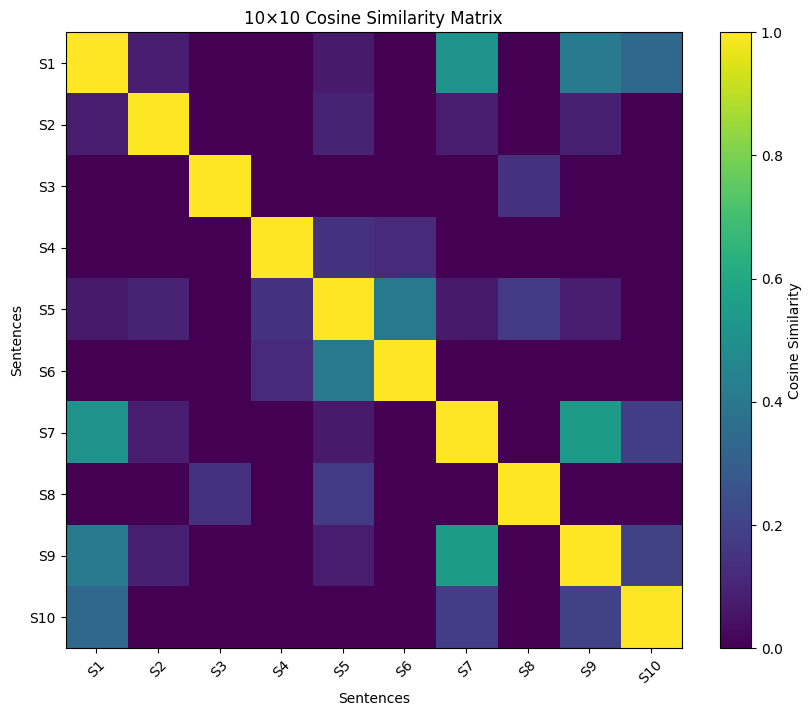

In [11]:
plt.figure(figsize=(10, 8))

plt.imshow(similarity_matrix)

plt.colorbar(label="Cosine Similarity")

plt.xticks(range(10), [f"S{i+1}" for i in range(10)], rotation=45)
plt.yticks(range(10), [f"S{i+1}" for i in range(10)])

plt.xlabel("Sentences")
plt.ylabel("Sentences")
plt.title("10×10 Cosine Similarity Matrix")

plt.show()

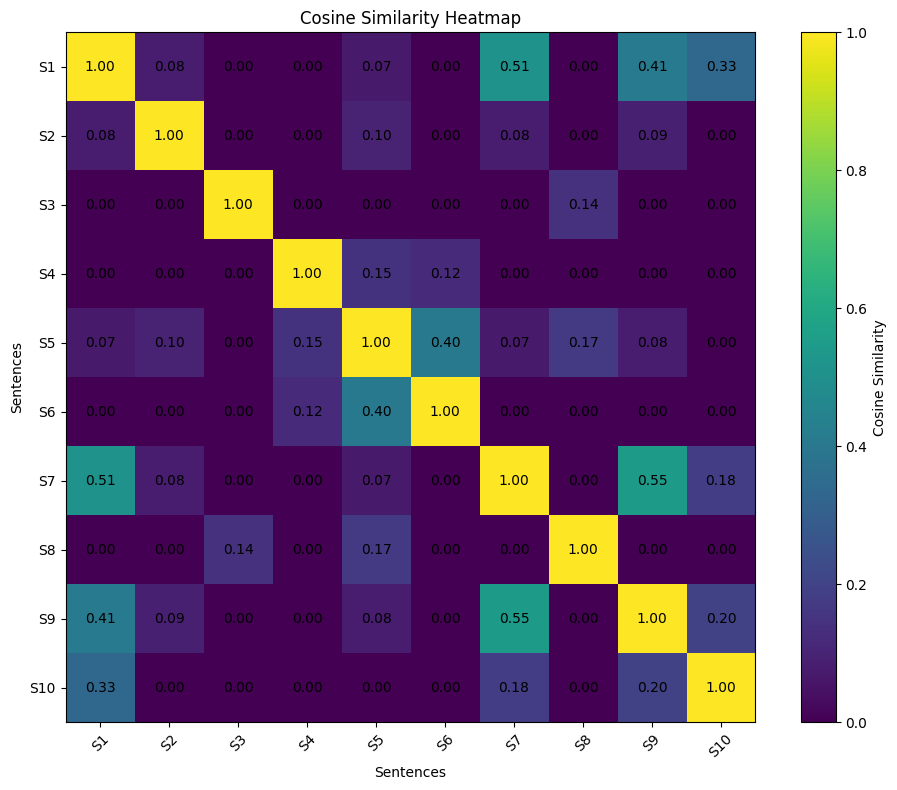

In [12]:
plt.figure(figsize=(10, 8))

plt.imshow(similarity_matrix)

plt.colorbar(label="Cosine Similarity")

labels = [f"S{i+1}" for i in range(10)]

plt.xticks(range(10), labels, rotation=45)
plt.yticks(range(10), labels)

for i in range(10):
    for j in range(10):
        plt.text(j, i, f"{similarity_matrix[i, j]:.2f}",
                 ha="center", va="center")

plt.xlabel("Sentences")
plt.ylabel("Sentences")
plt.title("Cosine Similarity Heatmap")

plt.tight_layout()
plt.show()

Computers cannot directly understand the meaning of plain text.
They need text to be converted into numerical representations.
TF-IDF converts sentences into numerical vectors based on word importance.
These vectors can then be compared mathematically using cosine similarity.

Cosine similarity measures the angle between two vectors rather than only
measuring their physical distance. For text data, this is useful because
the direction of a vector represents the pattern of words in a document.
Two texts with similar word patterns can have a high cosine similarity
even when their vector lengths are different.

Cosine Similarity = (A · B) / (||A|| × ||B||)